# ALCC on Facebook

This notebook explores the **average local clustering coefficient (ALCC)** on the Facebook ground-truth graph. The emphasis is on the node-centered view: rather than asking about wedge closure globally, we ask how clustered each node's neighborhood is.

## Metric definition used in this project

We follow the operational convention from the original repository code: for each node

$$C(v)=\begin{cases}
\frac{\Delta(v)}{\binom{d(v)}{2}}, & d(v)\ge 2 \\
0, & d(v)<2
\end{cases}$$

and then

$$\mathrm{ALCC}(G)=\frac{1}{|V|}\sum_{v\in V} C(v).$$

Interpretation: for the average node, how interconnected are its neighbors?

In [1]:

from pathlib import Path
import sys
import math
import itertools
import shutil

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'metrics.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR.parent

sys.path.insert(0, str(NOTEBOOK_DIR))
from metrics import (
    load_graph,
    unique_triangle_count,
    wedge_count,
    gcc,
    alcc,
    count_k_cliques,
    k_clique_density,
    higher_order_global_clustering,
    higher_order_average_local_clustering,
    higher_order_local_clustering,
    node_k_clique_membership_counts,
    gcd11,
    orca_node_orbits_4,
    gcm11_from_orbits,
    GCD11_ORBITS,
)

DATA_PATH = NOTEBOOK_DIR.parent / 'data' / 'gt_txt' / 'facebook.txt'
G = load_graph(DATA_PATH)
print(f'Loaded {DATA_PATH.name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')


Loading graph: 88234it [00:00, 691987.07it/s]


Loaded facebook.txt: 4039 nodes, 88234 edges


In [2]:

def induced_ego_subgraph(G, center=None, radius=1, max_nodes=40):
    if center is None:
        center = max(G.degree, key=lambda x: x[1])[0]
    nodes = set(nx.single_source_shortest_path_length(G, center, cutoff=radius).keys())
    H = G.subgraph(nodes).copy()
    if H.number_of_nodes() > max_nodes:
        nbrs = sorted(H.nodes(), key=lambda u: (-G.degree[u], u))[:max_nodes]
        H = G.subgraph(nbrs).copy()
    return center, H


def edge_df(G):
    return pd.DataFrame(sorted((min(u,v), max(u,v)) for u,v in G.edges()), columns=['u','v'])


In [3]:
alcc_value = alcc(G)
local_cc = nx.clustering(G)
pd.DataFrame([
    {'metric': 'ALCC', 'value': alcc_value},
    {'metric': 'mean(local_cc over all nodes)', 'value': np.mean(list(local_cc.values()))},
])

,metric,value
0,ALCC,0.605547
1,mean(local_cc over all nodes),0.605547


## Inspect nodewise local coefficients

Nodes with high local clustering sit inside tightly knit neighborhoods.

In [4]:
local_df = pd.DataFrame({
    'node': list(local_cc.keys()),
    'degree': [G.degree[u] for u in local_cc],
    'local_clustering': list(local_cc.values()),
}).sort_values(['local_clustering', 'degree'], ascending=[False, False])
local_df.head(20)

,node,degree,local_clustering
135,391,10,1.0
309,2324,10,1.0
78,3795,9,1.0
195,1057,9,1.0
218,1313,9,1.0
273,1924,9,1.0
306,2291,9,1.0
328,2535,9,1.0
502,3488,9,1.0
889,3916,9,1.0


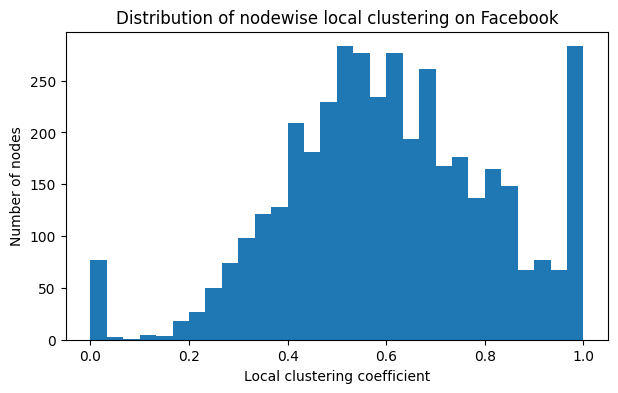

In [5]:
plt.figure(figsize=(7,4))
plt.hist(local_df['local_clustering'], bins=30)
plt.title('Distribution of nodewise local clustering on Facebook')
plt.xlabel('Local clustering coefficient')
plt.ylabel('Number of nodes')
plt.show()

## Node example

Pick one high-clustering node and manually inspect its neighbors.

In [6]:
row = local_df[local_df['degree'] >= 6].iloc[0]
node = int(row['node'])
neighbors = sorted(G.neighbors(node))
print('chosen node:', node)
print('degree:', G.degree[node])
print('local clustering:', local_cc[node])
print('neighbors:', neighbors[:30], '...' if len(neighbors) > 30 else '')

chosen node: 391
degree: 10
local clustering: 1.0
neighbors: [0, 302, 935, 1079, 1680, 2013, 2046, 2324, 2447, 2890] 


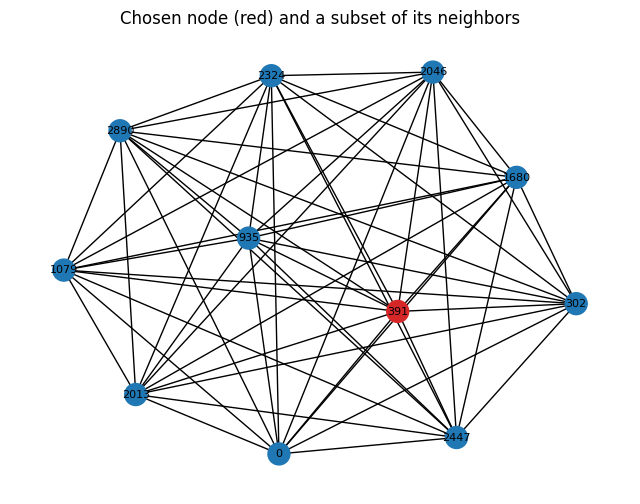

In [7]:
N = G.subgraph([node] + neighbors[:20]).copy()
pos = nx.spring_layout(N, seed=11)
plt.figure(figsize=(8,6))
colors = ['tab:red' if u == node else 'tab:blue' for u in N.nodes()]
nx.draw_networkx(N, pos=pos, node_color=colors, node_size=250, font_size=8)
plt.title('Chosen node (red) and a subset of its neighbors')
plt.axis('off')
plt.show()

In [8]:
nbrs = list(G.neighbors(node))
possible_pairs = math.comb(len(nbrs), 2)
closed_pairs = 0
for u, v in itertools.combinations(nbrs, 2):
    if G.has_edge(u, v):
        closed_pairs += 1
manual_local = closed_pairs / possible_pairs
pd.DataFrame([
    {'quantity': 'neighbor pairs', 'value': possible_pairs},
    {'quantity': 'connected neighbor pairs', 'value': closed_pairs},
    {'quantity': 'manual local clustering', 'value': manual_local},
    {'quantity': 'NetworkX local clustering', 'value': local_cc[node]},
])

,quantity,value
0,neighbor pairs,45.0
1,connected neighbor pairs,45.0
2,manual local clustering,1.0
3,NetworkX local clustering,1.0


## Interpretation

- **GCC** and **ALCC** are related, but not identical.
- GCC weights nodes implicitly by their wedge counts.
- ALCC gives each node equal influence in the final average.

For realism testing, missing ALCC means the generated graph fails to reproduce the average neighborhood tightness of the real Facebook graph.